# OMNeT++ result analysis

Reads CSV files exported by `opp_scavetool x` from `./data`, builds run summaries, saves processed tables, and saves figures under `data/figures/`.

The CDF section plots `CDF (%)` versus `time to completion (s)` for these lines when data is available: `Interest-CAP + Data-CAP`, `Interest-CAP + Data-CFP`, `Interest-CFP + Data-CAP`, `Data-CAP`, `Data-CFP`.

In [12]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = Path('data')
FIG_DIR = DATA_DIR / 'figures'
OUT_DIR = DATA_DIR / 'processed'
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

csv_files = sorted(DATA_DIR.glob('data_*.csv'), key=lambda p: p.stat().st_mtime)
if not csv_files:
    raise FileNotFoundError('No data_*.csv files found in ./data. Run: make -C ccnsim_dsme scavetool')

CSV_PATH = csv_files[-1]
CSV_PATH

WindowsPath('data/data_2026-05-24-13.45.34.csv')

In [13]:
def save_figure(fig, name, dpi=200):
    path = FIG_DIR / name
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f'Saved {path}')
    return path

def parse_bool(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, bool):
        return value
    text = str(value).strip().lower()
    if text in {'true', '1', 'yes', 'on'}:
        return True
    if text in {'false', '0', 'no', 'off'}:
        return False
    return np.nan

def parse_omnet_vector_cell(cell):
    if pd.isna(cell) or cell == '':
        return np.array([])
    return np.fromstring(str(cell), sep=' ')

def empirical_cdf(values):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return values, values
    x = np.sort(values)
    y = np.arange(1, len(x) + 1) / len(x) * 100
    return x, y

## Load CSV

In [14]:
raw = pd.read_csv(CSV_PATH, low_memory=False)
raw['value'] = pd.to_numeric(raw['value'], errors='coerce')

print(CSV_PATH)
print(raw.shape)
display(raw.head())
display(raw['type'].value_counts(dropna=False).rename('rows'))

data\data_2026-05-24-13.45.34.csv
(591370, 9)


,run,type,module,name,attrname,attrvalue,value,vectime,vecvalue
0,PUSH-0-20260524-08:03:35-23,runattr,NaN,NaN,configname,PUSH,NaN,NaN,NaN
1,PUSH-0-20260524-08:03:35-23,runattr,NaN,NaN,datetime,20260524-08:03:35,NaN,NaN,NaN
2,PUSH-0-20260524-08:03:35-23,runattr,NaN,NaN,datetimef,20260524-080335,NaN,NaN,NaN
3,PUSH-0-20260524-08:03:35-23,runattr,NaN,NaN,experiment,PUSH,NaN,NaN,NaN
4,PUSH-0-20260524-08:03:35-23,runattr,NaN,NaN,inifile,rfd_repos.ini,NaN,NaN,NaN


type
attr       271660
scalar     194446
config      99456
runattr     14640
itervar     11168
Name: rows, dtype: int64

## Split OMNeT++ record types and metadata

In [15]:
runattrs = raw.loc[raw['type'].eq('runattr'), ['run', 'attrname', 'attrvalue']].copy()
itervars = raw.loc[raw['type'].eq('itervar'), ['run', 'attrname', 'attrvalue']].copy()
configs = raw.loc[raw['type'].eq('config'), ['run', 'attrname', 'attrvalue']].copy()
params = raw.loc[raw['type'].eq('param')].copy()
scalars = raw.loc[raw['type'].eq('scalar')].copy()
vectors = raw.loc[raw['type'].eq('vector')].copy()

def pivot_attrs(df):
    if df.empty:
        return pd.DataFrame(index=pd.Index([], name='run'))
    out = df.dropna(subset=['attrname']).pivot_table(
        index='run', columns='attrname', values='attrvalue', aggfunc='first'
    )
    out.columns.name = None
    return out

runmeta = pivot_attrs(runattrs)
itermeta = pivot_attrs(itervars)
configmeta = pivot_attrs(configs)
meta = runmeta.join(itermeta, how='outer', rsuffix='_iter').join(configmeta, how='outer', rsuffix='_config')

for col in ['numRfd', 'numhosts', 'timeToNext', 'warmUp', 'numInterestRetries']:
    if col in meta.columns:
        meta[col] = pd.to_numeric(meta[col], errors='coerce')
for col in ['interestCFP', 'dataCFP', 'pushCFP']:
    if col in meta.columns:
        meta[col] = meta[col].map(parse_bool)
    else:
        meta[col] = np.nan

display(meta.head())
display(scalars['name'].value_counts().rename_axis('metric').reset_index(name='rows').head(80))

,configname,datetime,datetimef,experiment,inifile,iterationvars,iterationvarsf,measurement,network,processid,repetition,replication,resultdir,runnumber,seedset,clientType,dataCFP,dist,indicationCFP,interestCFP,iterationvarsd,numInterestRetries,numRfd,numhosts,pushCFP,timeToNext,totCont,warmUp,**.C,**.DS,**.FS,**.NC,**.RS,**.RTT,**.TTL1,**.TTL2,**.alpha,**.check_time,**.client_path_prefix,**.client_type,**.client_warmup,**.consThr,**.content_distribution_type,**.cvThr,**.datarate,**.defWinSize,**.downsize,**.dropProb,**.fail_duration,**.fail_scenario,...,**.node[*].wlan[*].mac.macMaxBE,**.node[*].wlan[*].mac.macMaxCSMABackoffs,**.node[*].wlan[*].mac.macMaxFrameRetries,**.node[*].wlan[*].mac.macMinBE,**.node[*].wlan[*].mac.macResponseWaitTime,**.node[*].wlan[*].mac.minBroadcastLQI,**.node[*].wlan[*].mac.minCoordinatorLQI,**.node[*].wlan[*].mac.multiSuperframeOrder,**.node[*].wlan[*].mac.sendMultiplePacketsPerGTS,**.node[*].wlan[*].mac.superframeOrder,**.node[*].wlan[*].radio.*.result-recording-modes,**.node[*].wlan[*].typename,**.node[0].wlan[*].mac.isPANCoordinator,**.node_repos,**.node_type,**.numHosts,**.numInterestRetries,**.num_repos,**.num_tot_req,**.objects,**.onlyModel,**.partial_n,**.perc_aggr,**.q,**.radioMedium.rangeFilter,**.radioMedium.typename,**.replicas,**.routing_file,**.shot_noise_file,**.start_mode,**.stat_aggr,**.steady,**.tc_file,**.tc_name_file,**.toff_mult_factor,**.ts,**.variance_threshold,**.window,cmdenv-output-file,cmdenv-redirect-output,constraint,eventlog-file,image-path,network_config,output-scalar-file,output-vector-file,repeat,sim-time-limit,simtime-scale,snapshot-file
run,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
INDICATION-0-20260524-10:32:46-436,INDICATION,20260524-10:32:46,20260524-103246,INDICATION,rfd_repos.ini,"$interestCFP=true, $dataCFP=true, $indicationC...","interestCFP=true,dataCFP=true,indicationCFP=tr...","$interestCFP=true, $dataCFP=true, $indicationC...",ccnsim_dsme_network,436,0,#0,results,0,0,indication,True,"""exponential""",true,True,interestCFP=true/dataCFP=true/indicationCFP=tr...,0.0,7,NaN,NaN,30,10000,NaN,100,"""lce""","""spr""",0,"""lru_cache""",125.82912,1000,1000,1,2,"""ccnsim_dsme.""","""client_indication""",NaN,0.1,"""ccnsim_dsme.content_distribution_ext""",0.05,1000000,1,1,0.01,200,false,...,5,4,3,3,32,150,150,5,false,3,"-histogram,-vector",DSMELoRaNic,true,"""1,2,3,4,5,6,7""","""ccnsim_dsme.ccnsim_dsme_node""",7 + 1,0,7,1e9,10000,true,0.75,1.0,0,"""interferenceRange""",ccnsim_dsme.LoRaDSMEMedium,1,"""""","""ShotNoiseScenario.txt""","""cold""",0.5,50000,"""./Tc_Values/tc_single_cache_NumCl_1_NumRep_1_...","""./tc_name_single_cache""",9,20,0.0001,100,results/20260524-10:32:46_INDICATION-0-2026052...,true,($numRfd < 112) || ($interestCFP == false) || ...,results/20260524-10:32:46_INDICATION-0-2026052...,../../inet/images,ccnsim_dsme_network,results/20260524-10:32:46_INDICATION-0-2026052...,results/20260524-10:32:46_INDICATION-0-2026052...,1,150000s,-8,results/20260524-10:32:46_INDICATION-0-2026052...
INDICATION-1-20260524-10:32:46-437,INDICATION,20260524-10:32:46,20260524-103246,INDICATION,rfd_repos.ini,"$interestCFP=true, $dataCFP=true, $indicationC...","interestCFP=true,dataCFP=true,indicationCFP=tr...","$interestCFP=true, $dataCFP=true, $indicationC...",ccnsim_dsme_network,437,0,#0,results,1,1,indication,True,"""exponential""",true,True,interestCFP=true/dataCFP=true/indicationCFP=tr...,0.0,14,NaN,NaN,30,10000,NaN,100,"""lce""","""spr""",0,"""lru_cache""",125.82912,1000,1000,1,2,"""ccnsim_dsme.""","""client_indication""",NaN,0.1,"""ccnsim_dsme.content_distribution_ext""",0.05,1000000,1,1,0.01,200,false,...,5,4,3,3,32,150,150,5,false,3,"-histogram,-vector",DSMELoRaNic,true,"""1,2,3,4,5,6,7,8,9,10,11,12,13,14""","""ccnsim_dsme.ccnsim_dsme_node""",14 + 1,0,14,1e9,10000,true,0.75,1.0,0,"""interferenceRange""",ccnsim_dsme.LoRaDSMEMedium,1,"""""","""ShotNoiseScenario.txt""","""cold""",0.5,50000,"""./Tc_Values/tc_sin

,metric,rows
0,requiredMultiSuperframeOrder,3108
1,x,3108
2,y,3108
3,z,3108
4,rcvdPkFromHl:count,3048
5,rcvdPkFromHl:sum(packetBytes),3048
6,passedUpPk:count,3048
7,passedUpPk:sum(packetBytes),3048
8,numUpperPacketsForCAP,3048
9,numUpperPacketsForGTS,3048


## Run summary

In [16]:
module_text = scalars['module'].fillna('').astype(str)
name_text = scalars['name'].fillna('').astype(str)
scalars = scalars.assign(
    module_text=module_text,
    name_text=name_text,
    node=module_text.str.extract(r'node\[(\d+)\]', expand=False).astype(float),
    client=module_text.str.extract(r'client\[(\d+)\]', expand=False).astype(float),
    submodule=module_text.str.replace(r'^.*node\[\d+\]\.', '', regex=True)
)

interesting_metrics = [
    'SentCCNPush:count', 'ReceivedCCNPush:count',
    'SentCCNInterest:count', 'ReceivedCCNInterest:count',
    'SentCCNData:count', 'ReceivedCCNData:count',
    'sentL2CCNFrame:count',
    'uncorruptedFrameReceived:count', 'corruptedFrameReceived:count',
    'unicastDataSentDown:count', 'broadDataSentDown:count',
    'dutyCycle:avg', 'dutyCycle:max',
    'queueLength:max', 'packetsTXPerSlot:mean', 'packetsRXPerSlot:mean',
    'avg_time', 'downloads',
]
available_metrics = [m for m in interesting_metrics if m in set(scalars['name'])]

run_metric = (
    scalars[scalars['name'].isin(available_metrics)]
    .groupby(['run', 'name'], as_index=False)['value'].sum()
    .pivot(index='run', columns='name', values='value')
    .fillna(0)
)
run_metric.columns.name = None
summary = meta.join(run_metric, how='left')

if {'ReceivedCCNPush:count', 'SentCCNPush:count'}.issubset(summary.columns):
    summary['push_delivery_ratio'] = np.where(
        summary['SentCCNPush:count'] > 0,
        summary['ReceivedCCNPush:count'] / summary['SentCCNPush:count'],
        np.nan,
    )

if {'uncorruptedFrameReceived:count', 'corruptedFrameReceived:count'}.issubset(summary.columns):
    total_rx = summary['uncorruptedFrameReceived:count'] + summary['corruptedFrameReceived:count']
    summary['phy_corruption_ratio'] = np.where(total_rx > 0, summary['corruptedFrameReceived:count'] / total_rx, np.nan)

display(summary.head())

,configname,datetime,datetimef,experiment,inifile,iterationvars,iterationvarsf,measurement,network,processid,repetition,replication,resultdir,runnumber,seedset,clientType,dataCFP,dist,indicationCFP,interestCFP,iterationvarsd,numInterestRetries,numRfd,numhosts,pushCFP,timeToNext,totCont,warmUp,**.C,**.DS,**.FS,**.NC,**.RS,**.RTT,**.TTL1,**.TTL2,**.alpha,**.check_time,**.client_path_prefix,**.client_type,**.client_warmup,**.consThr,**.content_distribution_type,**.cvThr,**.datarate,**.defWinSize,**.downsize,**.dropProb,**.fail_duration,**.fail_scenario,...,**.onlyModel,**.partial_n,**.perc_aggr,**.q,**.radioMedium.rangeFilter,**.radioMedium.typename,**.replicas,**.routing_file,**.shot_noise_file,**.start_mode,**.stat_aggr,**.steady,**.tc_file,**.tc_name_file,**.toff_mult_factor,**.ts,**.variance_threshold,**.window,cmdenv-output-file,cmdenv-redirect-output,constraint,eventlog-file,image-path,network_config,output-scalar-file,output-vector-file,repeat,sim-time-limit,simtime-scale,snapshot-file,ReceivedCCNData:count,ReceivedCCNInterest:count,ReceivedCCNPush:count,SentCCNData:count,SentCCNInterest:count,SentCCNPush:count,avg_time,broadDataSentDown:count,corruptedFrameReceived:count,downloads,dutyCycle:avg,dutyCycle:max,packetsRXPerSlot:mean,packetsTXPerSlot:mean,queueLength:max,sentL2CCNFrame:count,uncorruptedFrameReceived:count,unicastDataSentDown:count,push_delivery_ratio,phy_corruption_ratio
run,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
INDICATION-0-20260524-10:32:46-436,INDICATION,20260524-10:32:46,20260524-103246,INDICATION,rfd_repos.ini,"$interestCFP=true, $dataCFP=true, $indicationC...","interestCFP=true,dataCFP=true,indicationCFP=tr...","$interestCFP=true, $dataCFP=true, $indicationC...",ccnsim_dsme_network,436,0,#0,results,0,0,indication,True,"""exponential""",true,True,interestCFP=true/dataCFP=true/indicationCFP=tr...,0.0,7,NaN,NaN,30,10000,NaN,100,"""lce""","""spr""",0,"""lru_cache""",125.82912,1000,1000,1,2,"""ccnsim_dsme.""","""client_indication""",NaN,0.1,"""ccnsim_dsme.content_distribution_ext""",0.05,1000000,1,1,0.01,200,false,...,true,0.75,1.0,0,"""interferenceRange""",ccnsim_dsme.LoRaDSMEMedium,1,"""""","""ShotNoiseScenario.txt""","""cold""",0.5,50000,"""./Tc_Values/tc_single_cache_NumCl_1_NumRep_1_...","""./tc_name_single_cache""",9,20,0.0001,100,results/20260524-10:32:46_INDICATION-0-2026052...,true,($numRfd < 112) || ($interestCFP == false) || ...,results/20260524-10:32:46_INDICATION-0-2026052...,../../inet/images,ccnsim_dsme_network,results/20260524-10:32:46_INDICATION-0-2026052...,results/20260524-10:32:46_INDICATION-0-2026052...,1,150000s,-8,results/20260524-10:32:46_INDICATION-0-2026052...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INDICATION-1-20260524-10:32:46-437,INDICATION,20260524-10:32:46,20260524-103246,INDICATION,rfd_repos.ini,"$interestCFP=true, $dataCFP=true, $indicationC...","interestCFP=true,dataCFP=true,indicationCFP=tr...","$interestCFP=true, $dataCFP=true, $indicationC...",ccnsim_dsme_network,437,0,#0,results,1,1,indication,True,"""exponential""",true,True,interestCFP=true/dataCFP=true/indicationCFP=tr...,0.0,14,NaN,NaN,30,10000,NaN,100,"""lce""","""spr""",0,"""lru_cache""",125.82912,1000,1000,1,2,"""ccnsim_dsme.""","""client_indication""",NaN,0.1,"""ccnsim_dsme.content_distribution_ext""",0.05,1000000,1,1,0.01,200,false,...,true,0.75,1.0,0,"""interferenceRange""",ccnsim_dsme.LoRaDSMEMedium,1,"""""","""ShotNoiseScenario.txt""","""cold""",0.5,50000,"""./Tc_Values/tc_single_cache_NumCl_1_NumRep_1_...","""./tc_name_single_cache""",9,20,0.0001,100,results/20260524-10:32:46_INDICATION-1-2026052...,true,($numRfd < 112) || ($interestCFP == false) || ...,results/20260524-10:32:46_INDICATION-1-2026052...,../../inet/images,ccnsim_dsme_network,results/20260524-10:32:46_INDICATION-1-2026052...,results/20260524-10:32:46_INDICATION-1-2026052...,1,150000s,-8,results/20260524-10:32:46_INDICATION-1-2026052...,NaN,Na

## Aggregate plots and save figures

,configname,numRfd,timeToNext,interestCFP,dataCFP,pushCFP,numInterestRetries,ReceivedCCNData:count,ReceivedCCNInterest:count,ReceivedCCNPush:count,SentCCNData:count,SentCCNInterest:count,SentCCNPush:count,avg_time,broadDataSentDown:count,corruptedFrameReceived:count,downloads,dutyCycle:avg,dutyCycle:max,numhosts,packetsRXPerSlot:mean,packetsTXPerSlot:mean,phy_corruption_ratio,push_delivery_ratio,queueLength:max,sentL2CCNFrame:count,uncorruptedFrameReceived:count,unicastDataSentDown:count,warmUp
0,INDICATION,7,30,False,False,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,INDICATION,7,30,False,False,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,INDICATION,7,30,False,True,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,INDICATION,7,30,False,True,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,INDICATION,7,30,True,False,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,INDICATION,7,30,True,False,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,INDICATION,7,30,True,True,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,INDICATION,7,30,True,True,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,INDICATION,7,60,False,False,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,INDICATION,7,60,False,False,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved data\figures\push_delivery_ratio_vs_timeToNext.png
Saved data\figures\dutyCycle_avg_vs_timeToNext.png
Saved data\figures\phy_corruption_ratio_vs_timeToNext.png
Saved data\figures\SentCCNPush_count_vs_timeToNext.png
Saved data\figures\ReceivedCCNPush_count_vs_timeToNext.png


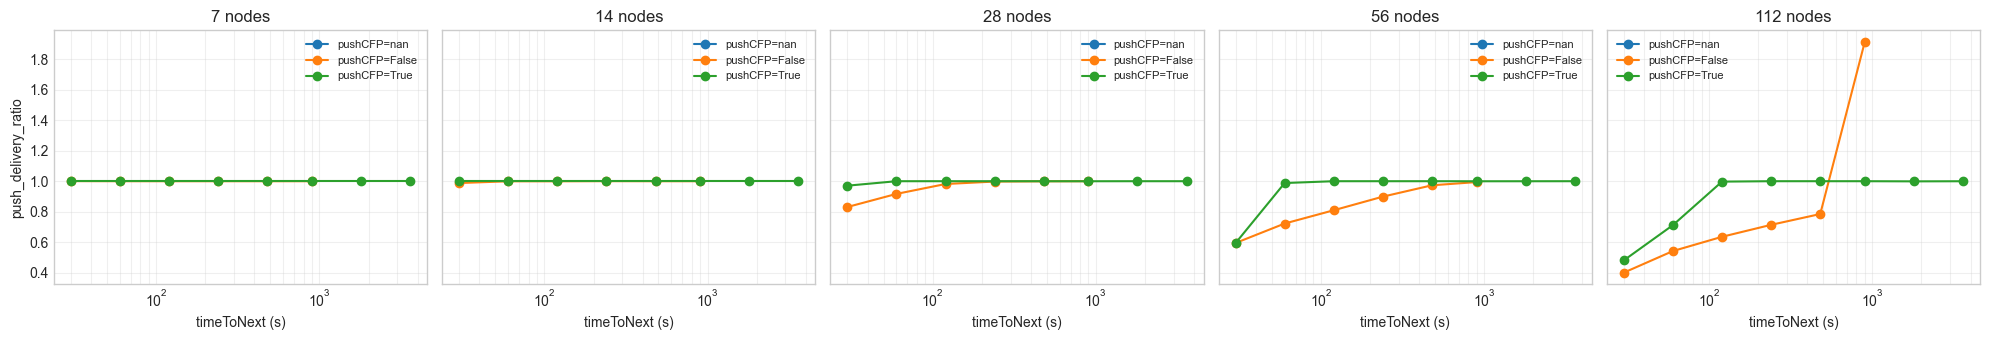

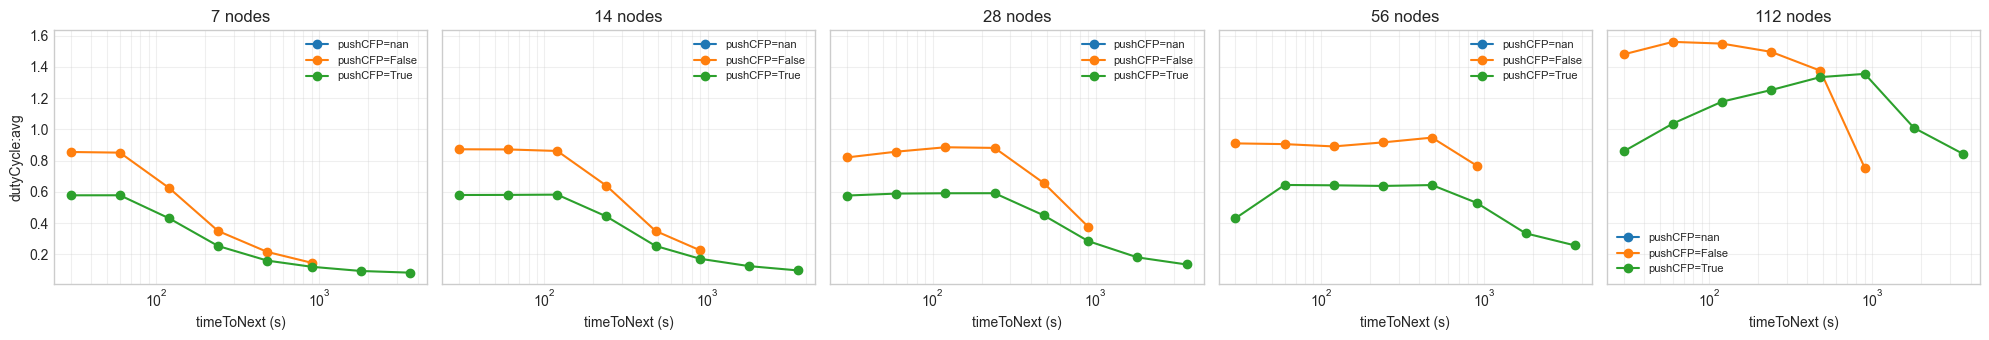

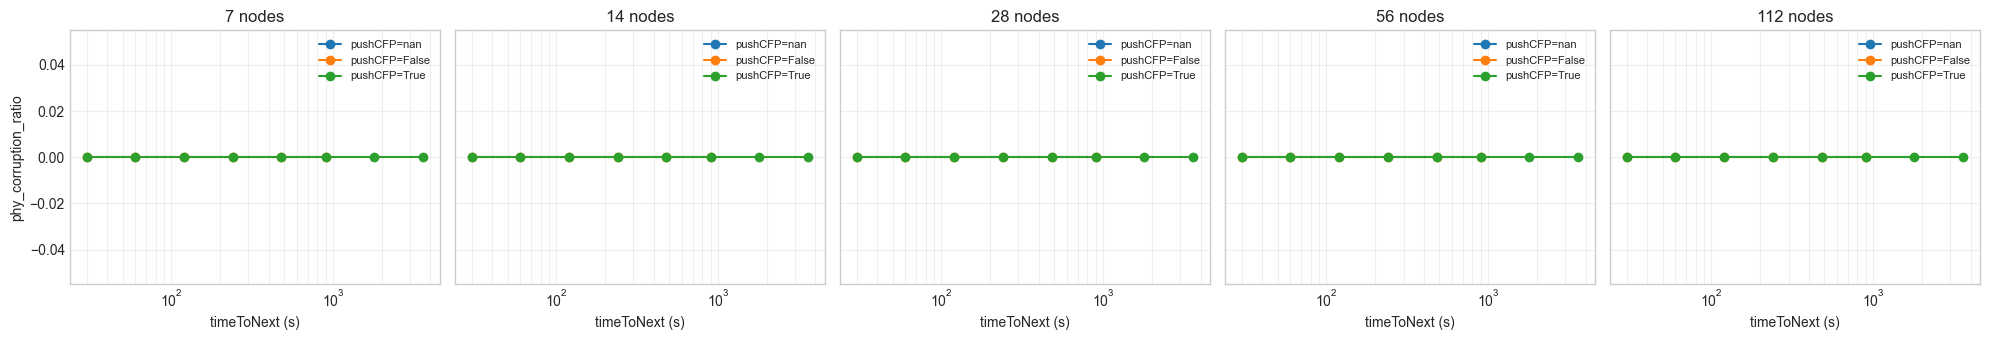

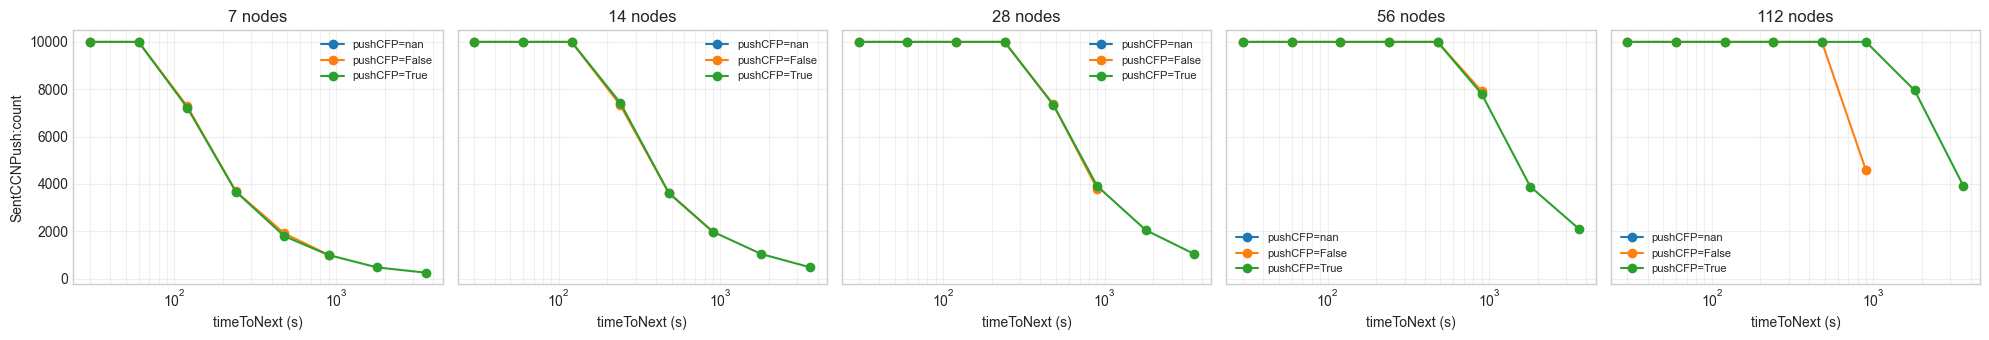

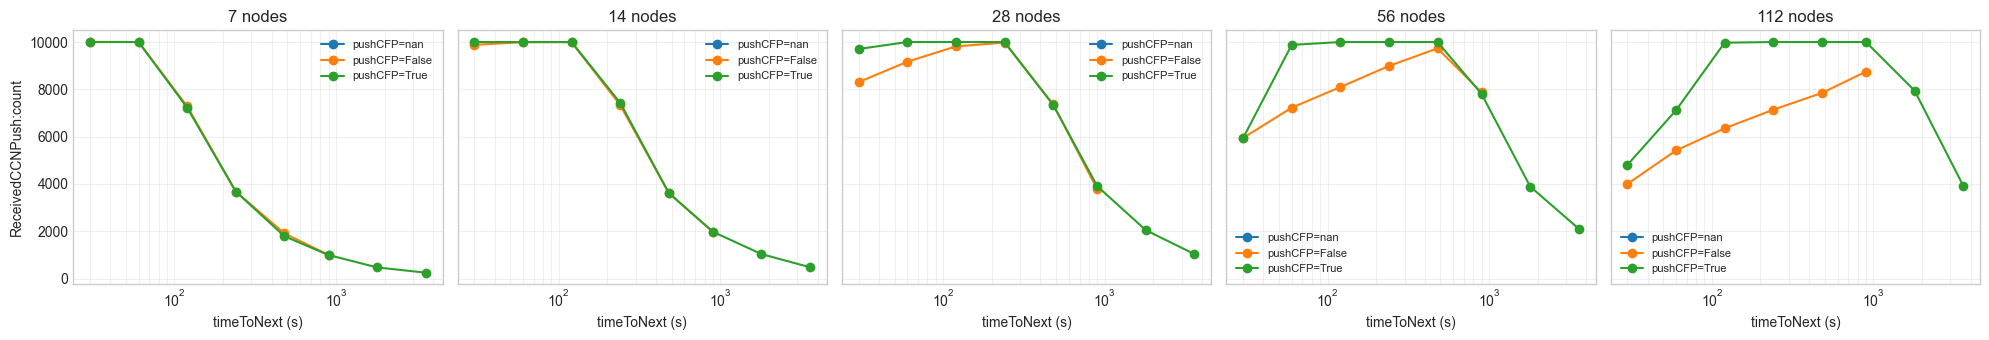

In [17]:
group_cols = [c for c in ['configname', 'numRfd', 'timeToNext', 'interestCFP', 'dataCFP', 'pushCFP', 'numInterestRetries'] if c in summary.columns]
numeric_cols = summary.select_dtypes(include='number').columns.difference(group_cols)

grouped = (
    summary.reset_index()
    .groupby(group_cols, dropna=False)[numeric_cols]
    .mean()
    .reset_index()
    .sort_values(group_cols)
)
display(grouped.head(100))

def plot_metric_vs_time(metric, by='pushCFP'):
    required = {'timeToNext', 'numRfd', metric}
    if not required.issubset(grouped.columns):
        print(f'Skip {metric}: missing {required - set(grouped.columns)}')
        return None

    facet_values = sorted(grouped['numRfd'].dropna().unique())
    if not facet_values:
        print(f'Skip {metric}: no numRfd values')
        return None

    fig, axes = plt.subplots(1, len(facet_values), figsize=(4 * len(facet_values), 3.5), sharey=True)
    if len(facet_values) == 1:
        axes = [axes]

    for ax, num_rfd in zip(axes, facet_values):
        part = grouped[grouped['numRfd'].eq(num_rfd)]
        if by in part.columns:
            for label, g in part.groupby(by, dropna=False):
                g = g.sort_values('timeToNext')
                ax.plot(g['timeToNext'], g[metric], marker='o', label=f'{by}={label}')
            ax.legend(fontsize=8)
        else:
            g = part.sort_values('timeToNext')
            ax.plot(g['timeToNext'], g[metric], marker='o')
        ax.set_title(f'{int(num_rfd)} nodes')
        ax.set_xlabel('timeToNext (s)')
        ax.set_xscale('log')
        ax.grid(True, which='both', alpha=0.3)
    axes[0].set_ylabel(metric)
    fig.tight_layout()
    save_figure(fig, f'{metric.replace(":", "_").replace("/", "_")}_vs_timeToNext.png')
    return fig

for metric in ['push_delivery_ratio', 'dutyCycle:avg', 'phy_corruption_ratio', 'SentCCNPush:count', 'ReceivedCCNPush:count']:
    if metric in grouped.columns:
        plot_metric_vs_time(metric)

## CDF of time to content arrival

This reproduces the paper-style layout: columns are network sizes, rows separate Gateway-initiated Interest/Data mappings from Node-initiated Data push.

Line mapping:

- `VANILLA` or `INDICATION` with `interestCFP=false`, `dataCFP=false`: `Interest-CAP + Data-CAP`
- `VANILLA` or `INDICATION` with `interestCFP=false`, `dataCFP=true`: `Interest-CAP + Data-CFP`
- `VANILLA` or `INDICATION` with `interestCFP=true`, `dataCFP=false`: `Interest-CFP + Data-CAP`
- `PUSH` with `pushCFP=false`: `Data-CAP`
- `PUSH` with `pushCFP=true`: `Data-CFP`

The x-axis is `Time to Content Arrival [s]`, and the y-axis is `CDF [%]`. The code filters `timeToNext` to `30s` and `900s` to match the reference figure.


In [18]:
TARGET_LINES = [
    'Interest-CAP + Data-CAP',
    'Interest-CAP + Data-CFP',
    'Interest-CFP + Data-CAP',
    'Data-CAP',
    'Data-CFP',
]
GATEWAY_INITIATED_LINES = [
    'Interest-CAP + Data-CAP',
    'Interest-CAP + Data-CFP',
    'Interest-CFP + Data-CAP',
]
NODE_INITIATED_LINES = ['Data-CAP', 'Data-CFP']
TARGET_NODES = [7, 14, 28, 56, 112]
TARGET_INTERVALS = [30, 900]

LINE_STYLES = {
    'Interest-CAP + Data-CAP': dict(color='red', linestyle='--', linewidth=2.0),
    'Interest-CAP + Data-CFP': dict(color='purple', linestyle=':', linewidth=3.0),
    'Interest-CFP + Data-CAP': dict(color='0.55', linestyle='-', linewidth=2.0),
    'Interest-CFP + Data-CFP': dict(color='black', linestyle='-.', linewidth=2.0),
    'Data-CAP': dict(color='green', linestyle=(0, (1, 1)), linewidth=2.0),
    'Data-CFP': dict(color='blue', linestyle='-', marker='o', markersize=3, linewidth=2.0),
}

def scenario_label(row):
    conf = str(row.get('configname', '')).upper()
    interest_cfp = parse_bool(row.get('interestCFP', np.nan))
    data_cfp = parse_bool(row.get('dataCFP', np.nan))
    push_cfp = parse_bool(row.get('pushCFP', np.nan))

    if conf in {'VANILLA', 'INDICATION'} and not pd.isna(interest_cfp) and not pd.isna(data_cfp):
        interest = 'Interest-CFP' if interest_cfp else 'Interest-CAP'
        data = 'Data-CFP' if data_cfp else 'Data-CAP'
        return f'{interest} + {data}'
    if conf == 'PUSH' and not pd.isna(push_cfp):
        return 'Data-CFP' if push_cfp else 'Data-CAP'
    return np.nan

meta_with_label = meta.copy()
meta_with_label['line'] = meta_with_label.apply(scenario_label, axis=1)
scenario_cols = ['configname', 'numRfd', 'timeToNext', 'interestCFP', 'dataCFP', 'pushCFP', 'line']
scenario_cols = [c for c in scenario_cols if c in meta_with_label.columns]
display(meta_with_label[scenario_cols].drop_duplicates().sort_values(['line', 'numRfd', 'timeToNext']).head(120))

,configname,numRfd,timeToNext,interestCFP,dataCFP,pushCFP,line
run,,,,,,,
PUSH-40-20260524-08:09:06-63,PUSH,7,30,NaN,NaN,False,Data-CAP
PUSH-45-20260524-08:10:01-68,PUSH,7,60,NaN,NaN,False,Data-CAP
PUSH-50-20260524-08:10:54-73,PUSH,7,120,NaN,NaN,False,Data-CAP
PUSH-55-20260524-08:12:35-78,PUSH,7,240,NaN,NaN,False,Data-CAP
PUSH-60-20260524-08:13:48-83,PUSH,7,480,NaN,NaN,False,Data-CAP
...,...,...,...,...,...,...,...
VANILLA-231-20260524-09:49:06-352,VANILLA,28,60,False,False,NaN,Interest-CAP + Data-CAP
INDICATION-444-20260524-12:25:31-880,INDICATION,28,120,False,False,NaN,Interest-CAP + Data-CAP
VANILLA-236-20260524-09:50:44-357,VANILLA,28,120,False,False,NaN,Interest-CAP + Data-CAP


In [19]:
def vector_series(metric_names):
    if vectors.empty:
        return pd.DataFrame(columns=['run', 'module', 'name', 'time', 'value'])
    data = vectors[vectors['name'].isin(metric_names)].copy()
    rows = []
    for _, row in data.iterrows():
        times = parse_omnet_vector_cell(row.get('vectime'))
        values = parse_omnet_vector_cell(row.get('vecvalue'))
        n = min(len(times), len(values))
        if n:
            rows.append(pd.DataFrame({
                'run': row['run'],
                'module': row['module'],
                'name': row['name'],
                'time': times[:n],
                'value': values[:n],
            }))
    if not rows:
        return pd.DataFrame(columns=['run', 'module', 'name', 'time', 'value'])
    return pd.concat(rows, ignore_index=True)

completion_event_names = ['ReceivedCCNData', 'ReceivedCCNPush', 'ReceivedCCNIndication', 'ReceivedCCNInterest']
completion_vectors = vector_series(completion_event_names)
completion_meta_cols = ['numRfd', 'timeToNext', 'line']

if not completion_vectors.empty:
    completion_samples = completion_vectors.merge(
        meta_with_label[completion_meta_cols], left_on='run', right_index=True, how='left'
    )
    completion_samples = completion_samples.rename(columns={'time': 'content_arrival_s'})
else:
    avg_mask = scalars['name_text'].str.match(r'^avg_time(\[\d+\])?$', na=False)
    completion_samples = scalars.loc[avg_mask, ['run', 'module', 'name', 'value']].copy()
    completion_samples = completion_samples.rename(columns={'value': 'content_arrival_s'})
    completion_samples = completion_samples.merge(
        meta_with_label[completion_meta_cols], left_on='run', right_index=True, how='left'
    )

completion_samples['content_arrival_s'] = pd.to_numeric(completion_samples['content_arrival_s'], errors='coerce')
completion_samples = completion_samples.dropna(subset=['numRfd', 'timeToNext', 'line', 'content_arrival_s'])
completion_samples = completion_samples[completion_samples['line'].isin(TARGET_LINES)]
completion_samples = completion_samples[completion_samples['numRfd'].isin(TARGET_NODES)]
completion_samples = completion_samples[completion_samples['timeToNext'].isin(TARGET_INTERVALS)]

# If vector timestamps are absolute simulation times and warmUp is available, uncomment this block
# to convert them to time since content generation/request.
# if not completion_vectors.empty and 'warmUp' in meta_with_label.columns:
#     warmup = pd.to_numeric(meta_with_label['warmUp'], errors='coerce')
#     completion_samples = completion_samples.merge(warmup.rename('warmUp_s'), left_on='run', right_index=True, how='left')
#     completion_samples['content_arrival_s'] = completion_samples['content_arrival_s'] - completion_samples['warmUp_s']

sample_counts = completion_samples.groupby(['timeToNext', 'numRfd', 'line']).size().rename('samples').reset_index()
display(sample_counts)
display(completion_samples.head())

,timeToNext,numRfd,line,samples
0,30,7,Data-CAP,1
1,30,7,Data-CFP,1
2,30,14,Data-CAP,1
3,30,14,Data-CFP,1
4,30,28,Data-CAP,1
5,30,28,Data-CFP,1
6,30,56,Data-CAP,1
7,30,56,Data-CFP,1
8,30,112,Data-CAP,7
9,30,112,Data-CFP,7


,run,module,name,content_arrival_s,numRfd,timeToNext,line
125343,PUSH-0-20260524-08:03:35-23,ccnsim_dsme_network.statistics,avg_time,0.0,7,30,Data-CFP
126660,PUSH-1-20260524-08:03:35-24,ccnsim_dsme_network.statistics,avg_time,0.0,14,30,Data-CFP
129118,PUSH-2-20260524-08:03:35-25,ccnsim_dsme_network.statistics,avg_time,0.0,28,30,Data-CFP
133858,PUSH-3-20260524-08:03:35-26,ccnsim_dsme_network.statistics,avg_time,0.0,56,30,Data-CFP
143162,PUSH-4-20260524-08:03:40-27,ccnsim_dsme_network.statistics,avg_time,0.0,112,30,Data-CFP


Interval 30s has samples, but all content_arrival_s values are 0. Plotting zeros as exported.
Saved data\figures\content_arrival_cdf_30s_interval.png
Interval 900s has samples, but all content_arrival_s values are 0. Plotting zeros as exported.
Saved data\figures\content_arrival_cdf_900s_interval.png


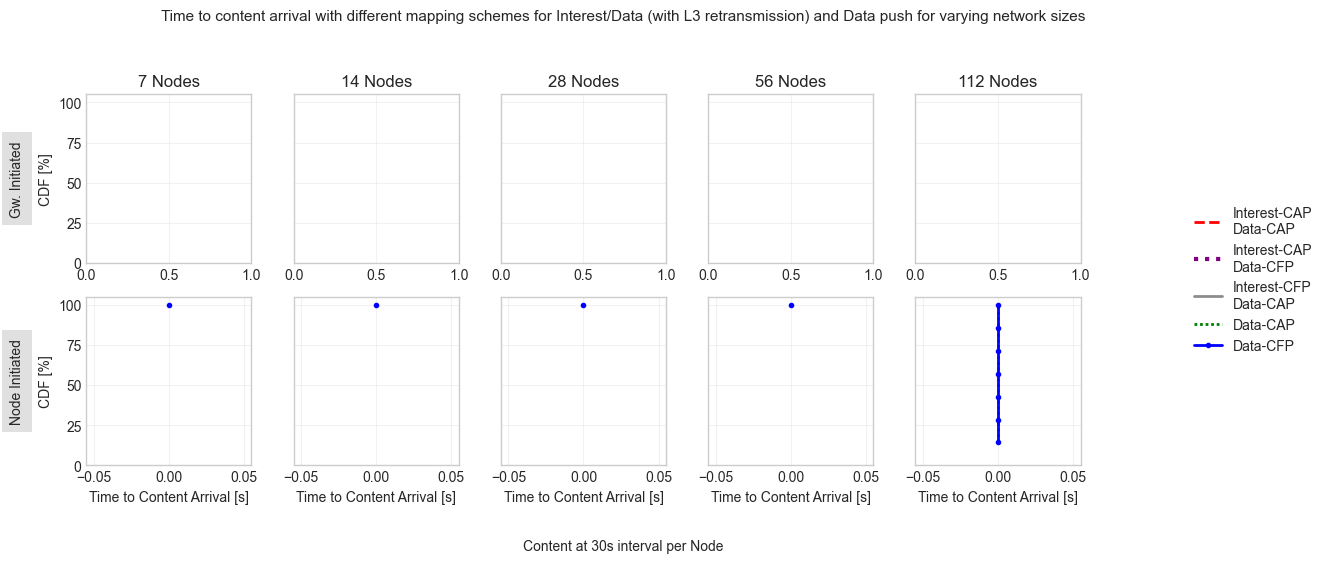

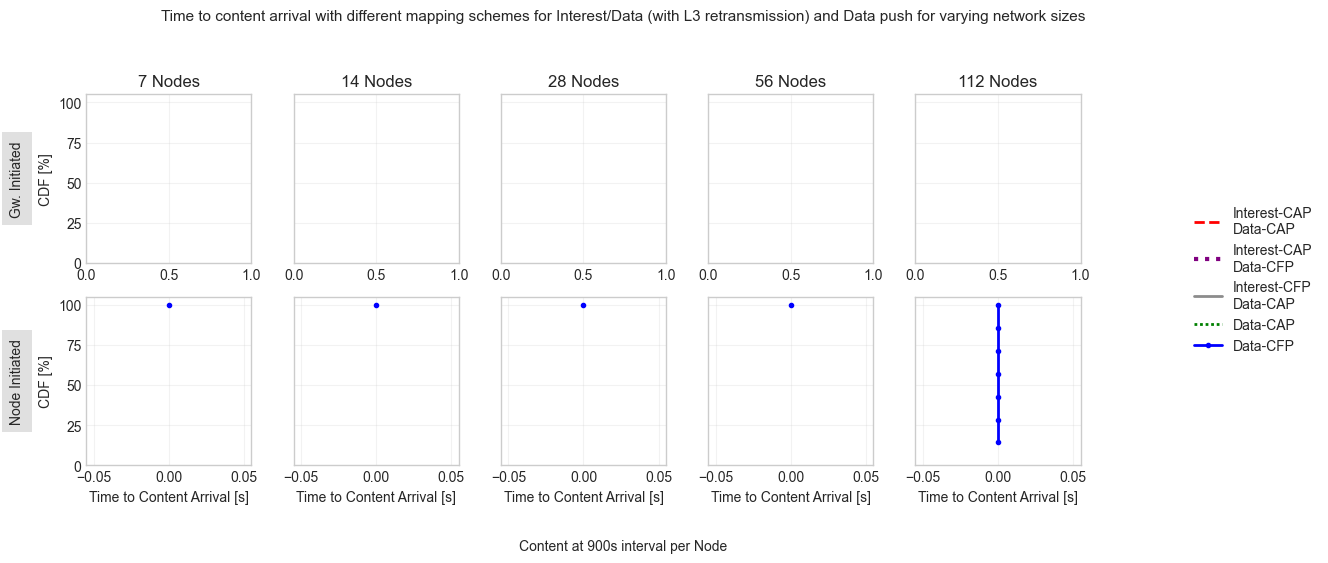

In [20]:
def plot_content_arrival_cdf_grid(samples, interval_s):
    """Plot CDF as in the paper: rows are traffic initiation direction, columns are network sizes."""
    part = samples[samples['timeToNext'].eq(interval_s)].copy()
    if part.empty:
        print(f'No content-arrival samples found for interval {interval_s}s.')
        return None

    nonzero = part[part['content_arrival_s'] > 0]
    if nonzero.empty:
        print(f'Interval {interval_s}s has samples, but all content_arrival_s values are 0. Plotting zeros as exported.')
        plot_data = part
    else:
        plot_data = nonzero

    fig, axes = plt.subplots(2, len(TARGET_NODES), figsize=(13.5, 5.2), sharey=True)
    row_specs = [
        ('Gw. Initiated', GATEWAY_INITIATED_LINES),
        ('Node Initiated', NODE_INITIATED_LINES),
    ]

    for row_idx, (row_label, lines) in enumerate(row_specs):
        for col_idx, nodes in enumerate(TARGET_NODES):
            ax = axes[row_idx, col_idx]
            cell = plot_data[plot_data['numRfd'].eq(nodes)]
            for line in lines:
                values = cell.loc[cell['line'].eq(line), 'content_arrival_s']
                x, y = empirical_cdf(values)
                if len(x):
                    ax.step(x, y, where='post', label=line, **LINE_STYLES.get(line, {}))
            if row_idx == 0:
                ax.set_title(f'{nodes} Nodes')
            if col_idx == 0:
                ax.set_ylabel('CDF [%]')
                ax.text(
                    -0.42, 0.5, row_label, transform=ax.transAxes, rotation=90,
                    va='center', ha='center', fontsize=10,
                    bbox=dict(facecolor='0.88', edgecolor='none', pad=6),
                )
            if row_idx == 1:
                ax.set_xlabel('Time to Content Arrival [s]')
            ax.set_ylim(0, 105)
            ax.set_yticks([0, 25, 50, 75, 100])
            ax.grid(True, alpha=0.25)

    handles, labels = [], []
    for line in TARGET_LINES:
        style = LINE_STYLES.get(line, {})
        handle = plt.Line2D([0], [0], label=line.replace(' + ', '\n'), **style)
        handles.append(handle)
        labels.append(line.replace(' + ', '\n'))
    fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.suptitle(
        'Time to content arrival with different mapping schemes for Interest/Data '
        '(with L3 retransmission) and Data push for varying network sizes',
        y=1.02,
        fontsize=11,
    )
    fig.text(0.5, -0.02, f'Content at {interval_s}s interval per Node', ha='center')
    fig.tight_layout(rect=[0.03, 0.04, 0.86, 0.98])
    save_figure(fig, f'content_arrival_cdf_{interval_s}s_interval.png')
    return fig

for interval_s in TARGET_INTERVALS:
    plot_content_arrival_cdf_grid(completion_samples, interval_s)

## Per-node scalar inspection

,run,node,value
0,PUSH-0-20260524-08:03:35-23,0.0,10000.0
1,PUSH-0-20260524-08:03:35-23,1.0,0.0
2,PUSH-0-20260524-08:03:35-23,2.0,0.0
3,PUSH-0-20260524-08:03:35-23,3.0,0.0
4,PUSH-0-20260524-08:03:35-23,4.0,0.0


Saved data\figures\per_node_received_ccn_push.png


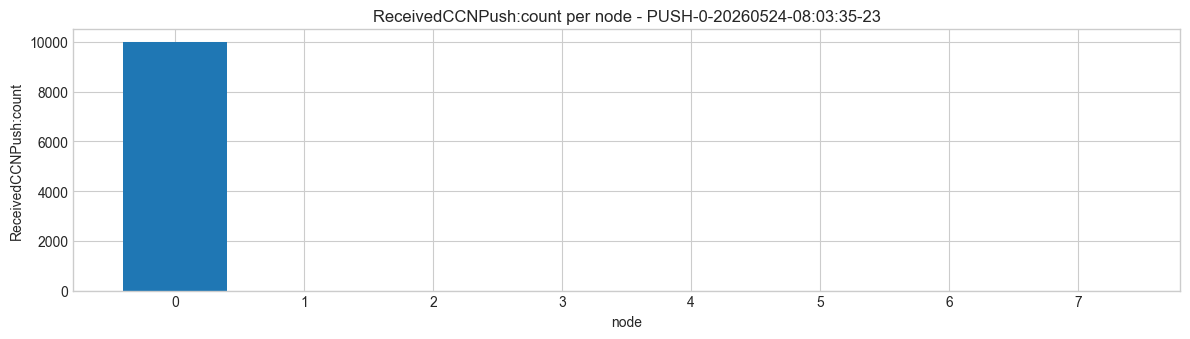

In [21]:
def per_node_metric(metric, run=None):
    data = scalars[scalars['name'].eq(metric)].copy()
    if run is not None:
        data = data[data['run'].eq(run)]
    data = data.dropna(subset=['node'])
    if data.empty:
        print(f'No data for {metric}')
        return pd.DataFrame()
    return data.groupby(['run', 'node'], as_index=False)['value'].sum()

metric = 'ReceivedCCNPush:count'
node_values = per_node_metric(metric)
display(node_values.head())

if not node_values.empty:
    example_run = node_values['run'].iloc[0]
    one = node_values[node_values['run'].eq(example_run)].sort_values('node')
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.bar(one['node'].astype(int), one['value'])
    ax.set_title(f'{metric} per node - {example_run}')
    ax.set_xlabel('node')
    ax.set_ylabel(metric)
    fig.tight_layout()
    save_figure(fig, 'per_node_received_ccn_push.png')

## Save processed tables

In [22]:
summary.to_csv(OUT_DIR / 'run_summary.csv')
grouped.to_csv(OUT_DIR / 'grouped_summary.csv', index=False)
completion_samples.to_csv(OUT_DIR / 'completion_samples.csv', index=False)
scalars['name'].value_counts().rename_axis('metric').reset_index(name='rows').to_csv(OUT_DIR / 'metric_counts.csv', index=False)

print('Wrote:')
print(OUT_DIR / 'run_summary.csv')
print(OUT_DIR / 'grouped_summary.csv')
print(OUT_DIR / 'completion_samples.csv')
print(OUT_DIR / 'metric_counts.csv')
print(f'Figures are saved in {FIG_DIR}')

Wrote:
data\processed\run_summary.csv
data\processed\grouped_summary.csv
data\processed\completion_samples.csv
data\processed\metric_counts.csv
Figures are saved in data\figures
